## 1. Setup and Configuration

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Basic imports
import torch
import numpy as np
import matplotlib.pyplot as plt
import logging
from pathlib import Path

# Set up logging
logging.basicConfig(level=logging.INFO)

# Analysis utils imports
from polarbert.analysis_utils import (
    load_config,
    load_pretrained_model,
    create_dataloaders,
    validate_model,
    create_mask,
    FlashTransformerAnalyzable,
    batch_to_device
)


In [3]:
# Load configuration using analysis utils
config_path = '/groups/pheno/inar/PolarBERT/configs/2027_08_polarbert_trap_IT.yaml'
batch_size = 256  # Smaller batch size for analysis

# The load_config function automatically sets CPU-friendly defaults
config = load_config(config_path, batch_size=batch_size)


train_loader, val_loader = create_dataloaders(config)


sample_batch, _ = next(iter(val_loader))
print(f"Sample batch shape: {sample_batch[0]['features'].shape}")
print(f"Sample DOM IDs shape: {sample_batch[0]['dom_id'].shape}")

INFO:root:Train loader ready: 507811 batches
INFO:root:Val loader ready: 780 batches
INFO:root:Logical batch size: 256
INFO:root:Val loader ready: 780 batches
INFO:root:Logical batch size: 256


Sample batch shape: torch.Size([256, 127, 3])
Sample DOM IDs shape: torch.Size([256, 127])


In [4]:
checkpoint_dir = "/groups/pheno/inar/PolarBERT/src/polarbert/checkpoints/results/PolarBERT-xyz-130M-8ep-trap_250907-135856"

# both work
pth_path = f"{checkpoint_dir}/final_model.pth"
ckpt_path = f"{checkpoint_dir}/last.ckpt"

checkpoint_path = pth_path 

# checkpoint_path = "/groups/pheno/inar/PolarBERT/src/polarbert/checkpoints/results/PolarBERT-xyz-130M-8ep-trap_250907-135856/epoch=07-step=253895.ckpt"

pretrained_model = load_pretrained_model(
    config=config,
    checkpoint_path=checkpoint_path,
    device='cuda',
    from_scratch=False
)

INFO:root:Loading checkpoint from: /groups/pheno/inar/PolarBERT/src/polarbert/checkpoints/results/PolarBERT-xyz-130M-8ep-trap_250907-135856/final_model.pth
INFO:root:Loaded pretrained weights successfully!
INFO:root:Loaded pretrained weights successfully!


In [5]:
pretrained_metrics = validate_model(
    model=pretrained_model,
    val_loader=val_loader,
    num_batches=128,
    device='cuda'
)
pretrained_metrics['avg_loss']

INFO:root:Validation metrics: {'avg_loss': 1.9491262333467603, 'accuracy': 0.28364830803271024, 'total_masked_tokens': 263037, 'total_correct_predictions': 74610, 'batches_processed': 128}


1.9491262333467603

In [6]:
batch = next(iter(val_loader))
batch = batch_to_device(batch, device='cuda')

sample_batch, _ = batch
print(f"Sample batch shape: {sample_batch[0]['features'].shape}")
print(f"Sample DOM IDs shape: {sample_batch[0]['dom_id'].shape}")

Sample batch shape: torch.Size([256, 127, 3])
Sample DOM IDs shape: torch.Size([256, 127])


In [7]:
fixed_mask = create_mask(
    sample_batch=sample_batch,
    config=config,
    seed=42,  # Fixed seed for reproducibility
    mask_prob=None  # Use config default
)

# Extract true DOM IDs for masked positions
true_dom_ids = sample_batch[0]['dom_id'][fixed_mask].cpu().numpy()
features = sample_batch[0]['features']
auxiliary_mask = features[:, :, 2] < 0  # Tokens eligible for masking
eligible_tokens = auxiliary_mask.sum().item()

print(f"Eligible tokens (aux < 0): {eligible_tokens}")
print(f"Actually masked: {fixed_mask.sum().item()}")
print(f"Masking rate: {fixed_mask.sum().item() / eligible_tokens * 100:.1f}%")

INFO:root:Created mask with 2213 masked tokens out of 8872 eligible tokens


Eligible tokens (aux < 0): 8872
Actually masked: 2213
Masking rate: 24.9%


In [8]:
pretrained_model.embedding.set_manual_mask(fixed_mask)

In [9]:

with torch.no_grad():
    # Get predictions from both models
    logits, mask, charge, padding_mask = pretrained_model(sample_batch)

In [10]:
torch.equal(fixed_mask, mask)

True

# 2. Plotting

In [11]:
(x, l) = sample_batch

In [13]:
x['dom_id']

tensor([[1392, 1451, 3087,  ...,    0,    0,    0],
        [4895, 2162, 1197,  ...,    0,    0,    0],
        [1233, 3337, 5140,  ...,    0,    0,    0],
        ...,
        [1871, 1976, 1445,  ...,    0,    0,    0],
        [4202, 3541, 2235,  ...,    0,    0,    0],
        [1250, 1063,   43,  ...,    0,    0,    0]], device='cuda:0')

In [14]:
# Simple setup for plotting
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# Load sensor geometry
geometry_df = pd.read_csv('/groups/pheno/inar/icecube_kaggle/sensor_geometry.csv')

# Create position tensor (5161 DOMs total, index 0 is padding)
positions = torch.zeros(5161, 3)  # +1 for padding DOM at index 0
for i in range(len(geometry_df)):
    positions[i + 1] = torch.tensor([geometry_df.iloc[i]['x'], 
                                   geometry_df.iloc[i]['y'], 
                                   geometry_df.iloc[i]['z']])

def plot_event(x, event_idx, positions, geometry_df, size_scale=100):
    """Simple event plotting function"""
    # Get event data
    dom_ids = x['dom_id'][event_idx].cpu().numpy()
    features = x['features'][event_idx].cpu().numpy()
    
    # Remove padding (DOM ID = 0)
    valid_mask = dom_ids > 0
    dom_ids = dom_ids[valid_mask]
    times = features[valid_mask, 0]
    charges = features[valid_mask, 1]
    
    print(f"Event {event_idx}: {len(dom_ids)} pulses")
    print(f"Charge range: {charges.min():.2f} to {charges.max():.2f}")
    print(f"Size scale: {size_scale}")
    
    # Get positions for this event
    event_positions = positions[dom_ids].numpy()
    
    # Create 3D plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot all DOMs as small gray points
    ax.scatter(geometry_df['x'], geometry_df['y'], geometry_df['z'], 
               c='gray', s=1, alpha=0.3)
    
    # Plot event pulses colored by time, sized by charge with adjustable scaling
    scatter = ax.scatter(event_positions[:, 0], event_positions[:, 1], event_positions[:, 2],
                        c=times, s=charges*size_scale, cmap='viridis', alpha=0.8)
    
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_zlabel('z (m)')
    
    plt.show()


In [25]:
print({idx: ll.item() for idx, ll in enumerate(l)})

{0: 66, 1: 51, 2: 57, 3: 44, 4: 39, 5: 46, 6: 127, 7: 59, 8: 47, 9: 55, 10: 127, 11: 127, 12: 74, 13: 58, 14: 103, 15: 50, 16: 53, 17: 116, 18: 76, 19: 77, 20: 73, 21: 100, 22: 127, 23: 127, 24: 53, 25: 114, 26: 127, 27: 97, 28: 45, 29: 60, 30: 75, 31: 100, 32: 36, 33: 44, 34: 40, 35: 113, 36: 42, 37: 97, 38: 108, 39: 66, 40: 39, 41: 127, 42: 124, 43: 101, 44: 57, 45: 35, 46: 45, 47: 70, 48: 62, 49: 62, 50: 95, 51: 86, 52: 60, 53: 127, 54: 48, 55: 82, 56: 43, 57: 56, 58: 127, 59: 49, 60: 71, 61: 30, 62: 76, 63: 45, 64: 40, 65: 127, 66: 107, 67: 127, 68: 74, 69: 127, 70: 55, 71: 38, 72: 55, 73: 85, 74: 46, 75: 127, 76: 69, 77: 40, 78: 66, 79: 32, 80: 127, 81: 45, 82: 55, 83: 126, 84: 63, 85: 40, 86: 93, 87: 60, 88: 40, 89: 93, 90: 66, 91: 87, 92: 39, 93: 53, 94: 58, 95: 127, 96: 40, 97: 62, 98: 60, 99: 53, 100: 76, 101: 127, 102: 66, 103: 58, 104: 127, 105: 85, 106: 84, 107: 104, 108: 66, 109: 54, 110: 67, 111: 80, 112: 57, 113: 127, 114: 53, 115: 40, 116: 45, 117: 80, 118: 62, 119: 62,

Event 22: 127 pulses
Charge range: -0.30 to 0.16
Size scale: 500


/lustre/hpc/pheno/inar/mambaforge/envs/polarbert/lib/python3.11/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


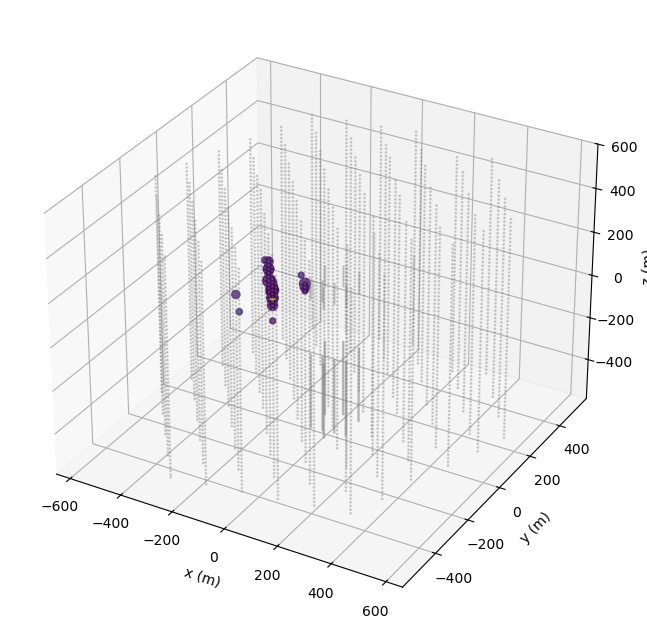

In [26]:
plot_event(x, 22, positions, geometry_df, size_scale=500)

In [18]:
def plot_event_with_masks(x, event_idx, mask, positions, geometry_df, size_scale=100):
    """Plot event with masked pulses shown as red crosses"""
    # Get event data
    dom_ids = x['dom_id'][event_idx].cpu().numpy()
    features = x['features'][event_idx].cpu().numpy()
    event_mask = mask[event_idx].cpu().numpy()
    
    # Remove padding (DOM ID = 0)
    valid_mask = dom_ids > 0
    dom_ids = dom_ids[valid_mask]
    times = features[valid_mask, 0]
    charges = features[valid_mask, 1]
    event_mask = event_mask[valid_mask]
    
    print(f"Event {event_idx}: {len(dom_ids)} pulses, {event_mask.sum()} masked")
    print(f"Charge range: {charges.min():.2f} to {charges.max():.2f}")
    print(f"Size scale: {size_scale}")
    
    # Get positions for this event
    event_positions = positions[dom_ids].numpy()
    
    # Separate masked and unmasked pulses
    masked_positions = event_positions[event_mask]
    unmasked_positions = event_positions[~event_mask]
    masked_times = times[event_mask]
    unmasked_times = times[~event_mask]
    masked_charges = charges[event_mask]
    unmasked_charges = charges[~event_mask]
    
    # Create 3D plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot all DOMs as small gray points
    ax.scatter(geometry_df['x'], geometry_df['y'], geometry_df['z'], 
               c='gray', s=1, alpha=0.3)
    
    # Plot unmasked pulses (normal visualization)
    if len(unmasked_positions) > 0:
        scatter = ax.scatter(unmasked_positions[:, 0], unmasked_positions[:, 1], unmasked_positions[:, 2],
                            c=unmasked_times, s=(0.05+unmasked_charges)*size_scale, cmap='viridis', alpha=0.8)
    
    # Plot masked pulses as red crosses
    if len(masked_positions) > 0:
        ax.scatter(masked_positions[:, 0], masked_positions[:, 1], masked_positions[:, 2],
                   c='red', s=0.1*size_scale, marker='x', alpha=1.0, linewidths=2)
    
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_zlabel('z (m)')
    
    plt.show()



In [57]:
def plot_masked_predictions_vectorized(x, event_idx, mask, logits, positions, geometry_df, 
                                     size_scale=100, top_k=500, max_plots=3):
    """Fully vectorized fast 2D plotting of model predictions for each masked pulse"""
    # Get event data
    dom_ids = x['dom_id'][event_idx].cpu().numpy()
    features = x['features'][event_idx].cpu().numpy()
    event_mask = mask[event_idx].cpu().numpy()
    event_logits = logits[event_idx].cpu().numpy()
    
    # Remove padding (DOM ID = 0)
    valid_mask = dom_ids > 0
    dom_ids = dom_ids[valid_mask]
    times = features[valid_mask, 0]
    charges = features[valid_mask, 1]
    event_mask = event_mask[valid_mask]
    event_logits = event_logits[valid_mask]
    
    # Find masked positions
    masked_indices = np.where(event_mask)[0]
    
    # Limit for development
    n_plots = min(len(masked_indices), max_plots)
    masked_indices = masked_indices[:n_plots]
    
    print(f"Event {event_idx}: {len(dom_ids)} pulses, {event_mask.sum()} masked")
    print(f"Creating {n_plots} vectorized plots (y-z projection, top {top_k})...")
    
    # Convert logits to probabilities for all masked positions
    masked_logits = event_logits[event_mask]  # Shape: (num_masked, vocab_size)
    masked_probs = torch.softmax(torch.tensor(masked_logits), dim=-1).numpy()
    
    # Pre-compute positions for all DOMs (vectorized)
    all_positions = positions.numpy()  # Shape: (5161, 3)
    
    for i, masked_idx in enumerate(masked_indices):
        # Get the masked pulse info
        masked_dom_id = dom_ids[masked_idx]
        masked_position = all_positions[masked_dom_id]
        
        # Get prediction probabilities for this masked pulse
        probs = masked_probs[i]  # Shape: (vocab_size,)
        
        # Get top-k predictions (vectorized)
        top_indices = np.argsort(probs)[-top_k:]
        top_probs = probs[top_indices]
        
        # Filter valid DOM IDs
        valid_dom_mask = (top_indices > 0) & (top_indices < len(all_positions))
        valid_indices = top_indices[valid_dom_mask]
        valid_probs = top_probs[valid_dom_mask]
        
        if len(valid_indices) == 0:
            continue
            
        # Get positions for valid predictions (vectorized)
        pred_positions = all_positions[valid_indices]  # Shape: (N, 3)
        
        # Compute alphas and sizes (vectorized)
        alphas = np.maximum(0.001, valid_probs)
        sizes = 50 + valid_probs * 200
        
        # Create 2D plot (y vs z projection)
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Plot background DOMs (vectorized)
        ax.scatter(geometry_df['y'], geometry_df['z'], c='lightgray', s=0.3, alpha=0.2, zorder=1)
        
        # Plot all top predictions at once (vectorized!)
        ax.scatter(pred_positions[:, 1], pred_positions[:, 2], c='blue', s=sizes, alpha=alphas, zorder=2)
        
        # Plot the specific masked pulse as red cross
        ax.scatter(masked_position[1], masked_position[2],
                   c='red', s=size_scale*0.2, marker='x', alpha=1.0, linewidths=3, zorder=3)
        
        # Get prediction info
        true_dom_id = masked_dom_id
        predicted_dom_id = np.argmax(probs)
        prediction_confidence = probs[predicted_dom_id]
        
        ax.set_xlabel('y (m)')
        ax.set_ylabel('z (m)')
        # ax.set_title(f'Pulse {i+1}/{n_plots} - True: DOM {true_dom_id}, Pred: DOM {predicted_dom_id} (conf: {prediction_confidence:.3f})')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        
        # Set reasonable limits
        ax.set_xlim([-600, 600])
        ax.set_ylim([-600, 600])
        
        plt.tight_layout()
        plt.show()
        
        print(f"Pulse {i+1}: True DOM {true_dom_id} -> Predicted DOM {predicted_dom_id} (confidence: {prediction_confidence:.3f})")
        
        # Add distance info
        if predicted_dom_id > 0 and predicted_dom_id < len(all_positions):
            pred_pos = all_positions[predicted_dom_id]
            distance = np.linalg.norm(masked_position - pred_pos)
            print(f"         Distance from true position: {distance:.1f}m")

print("Vectorized function loaded!")
print("Usage: plot_masked_predictions_vectorized(x, 11, mask, logits, positions, geometry_df, max_plots=2)")

Vectorized function loaded!
Usage: plot_masked_predictions_vectorized(x, 11, mask, logits, positions, geometry_df, max_plots=2)


## Plots

In [58]:
print({idx: ll.item() for idx, ll in enumerate(l)})


{0: 66, 1: 51, 2: 57, 3: 44, 4: 39, 5: 46, 6: 127, 7: 59, 8: 47, 9: 55, 10: 127, 11: 127, 12: 74, 13: 58, 14: 103, 15: 50, 16: 53, 17: 116, 18: 76, 19: 77, 20: 73, 21: 100, 22: 127, 23: 127, 24: 53, 25: 114, 26: 127, 27: 97, 28: 45, 29: 60, 30: 75, 31: 100, 32: 36, 33: 44, 34: 40, 35: 113, 36: 42, 37: 97, 38: 108, 39: 66, 40: 39, 41: 127, 42: 124, 43: 101, 44: 57, 45: 35, 46: 45, 47: 70, 48: 62, 49: 62, 50: 95, 51: 86, 52: 60, 53: 127, 54: 48, 55: 82, 56: 43, 57: 56, 58: 127, 59: 49, 60: 71, 61: 30, 62: 76, 63: 45, 64: 40, 65: 127, 66: 107, 67: 127, 68: 74, 69: 127, 70: 55, 71: 38, 72: 55, 73: 85, 74: 46, 75: 127, 76: 69, 77: 40, 78: 66, 79: 32, 80: 127, 81: 45, 82: 55, 83: 126, 84: 63, 85: 40, 86: 93, 87: 60, 88: 40, 89: 93, 90: 66, 91: 87, 92: 39, 93: 53, 94: 58, 95: 127, 96: 40, 97: 62, 98: 60, 99: 53, 100: 76, 101: 127, 102: 66, 103: 58, 104: 127, 105: 85, 106: 84, 107: 104, 108: 66, 109: 54, 110: 67, 111: 80, 112: 57, 113: 127, 114: 53, 115: 40, 116: 45, 117: 80, 118: 62, 119: 62,

Event 65: 127 pulses, 24 masked
Charge range: -0.30 to 0.17
Size scale: 500


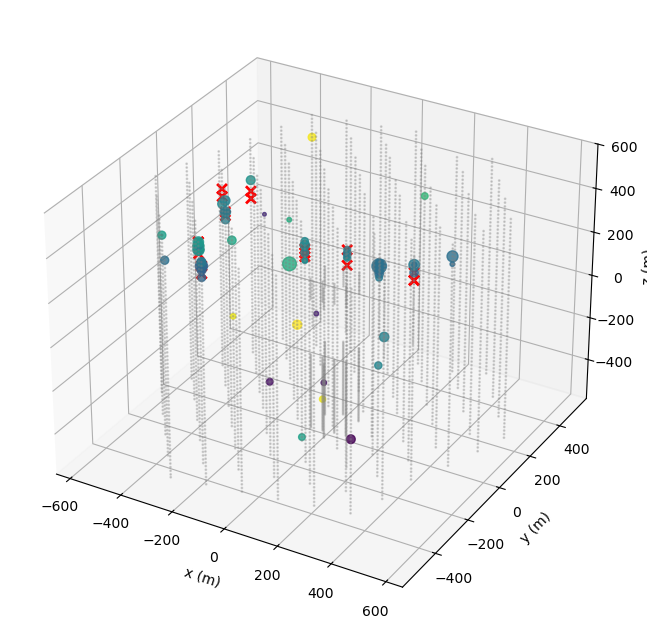

In [59]:

plot_event_with_masks(x, 65, mask, positions, geometry_df, size_scale=500)

Event 65: 127 pulses, 24 masked
Creating 10 vectorized plots (y-z projection, top 5000)...


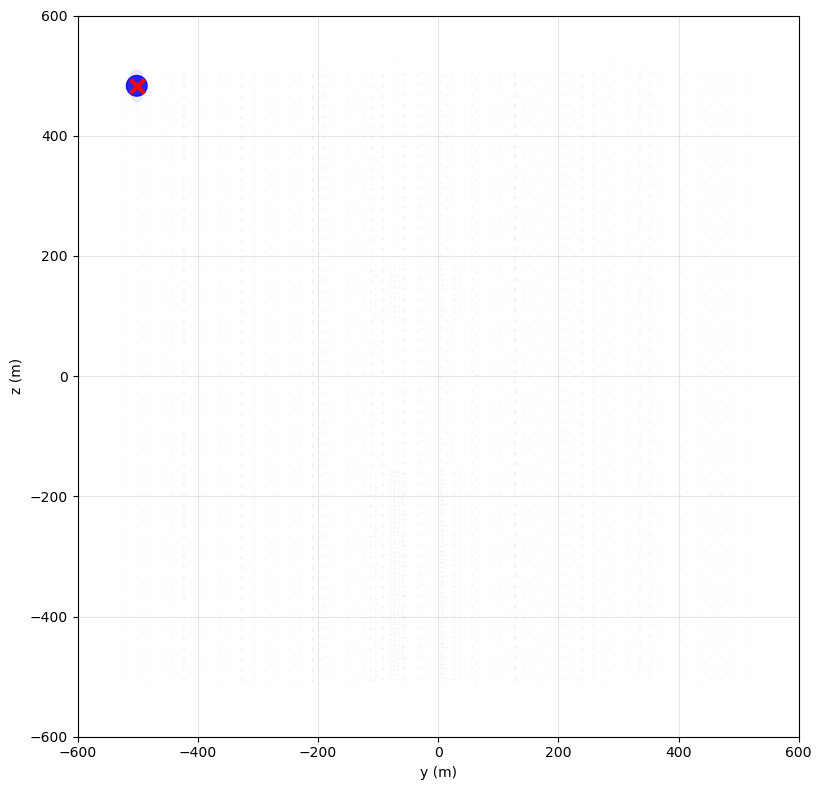

Pulse 1: True DOM 62 -> Predicted DOM 62 (confidence: 0.853)
         Distance from true position: 0.0m


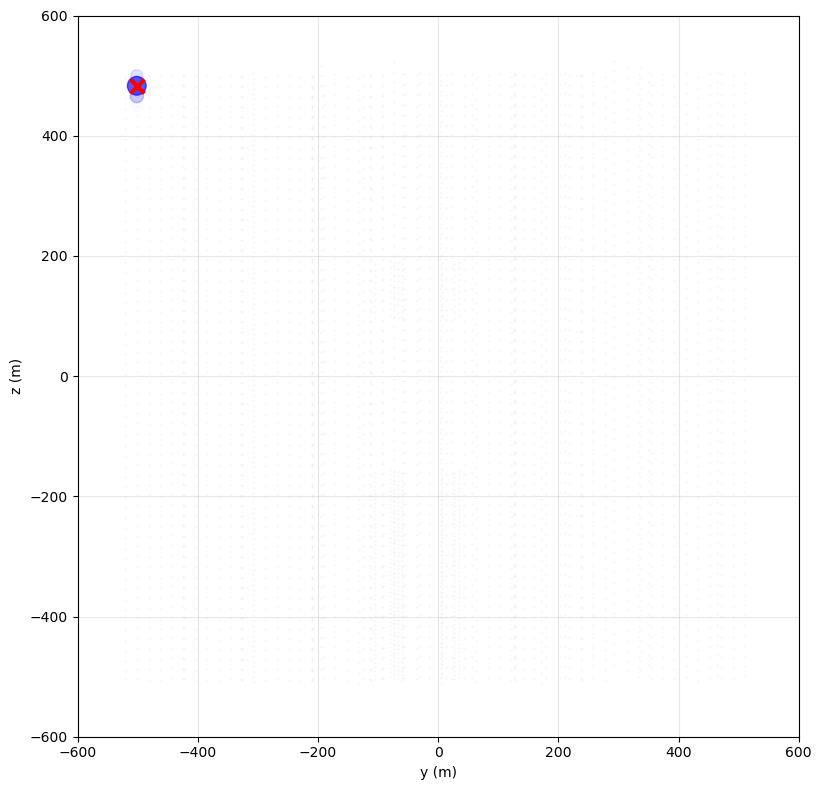

Pulse 2: True DOM 62 -> Predicted DOM 62 (confidence: 0.651)
         Distance from true position: 0.0m


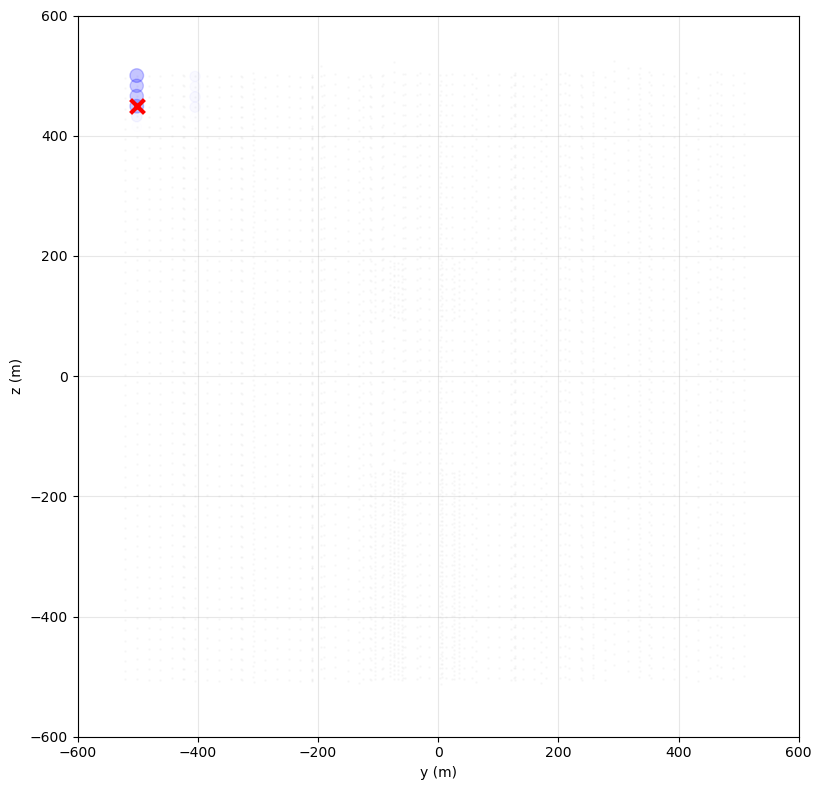

Pulse 3: True DOM 64 -> Predicted DOM 61 (confidence: 0.229)
         Distance from true position: 51.1m


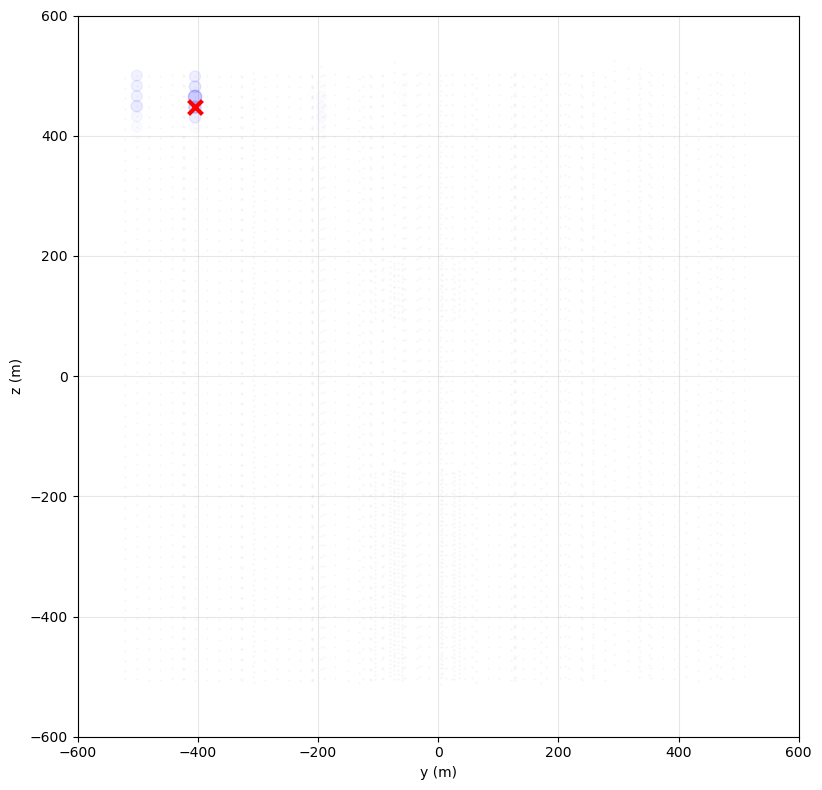

Pulse 4: True DOM 424 -> Predicted DOM 423 (confidence: 0.206)
         Distance from true position: 17.0m


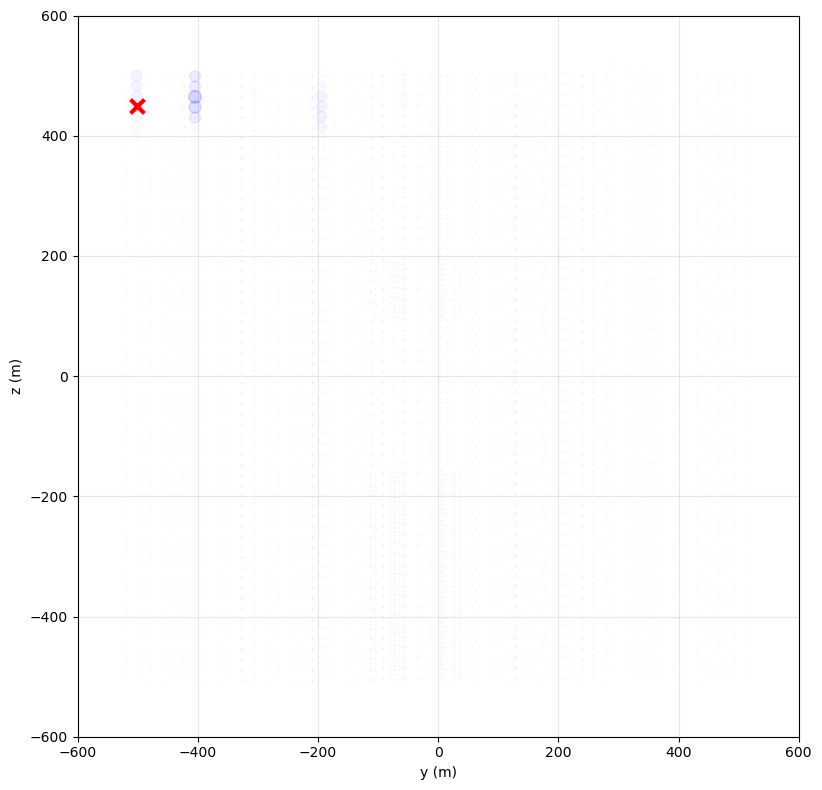

Pulse 5: True DOM 64 -> Predicted DOM 423 (confidence: 0.161)
         Distance from true position: 125.8m


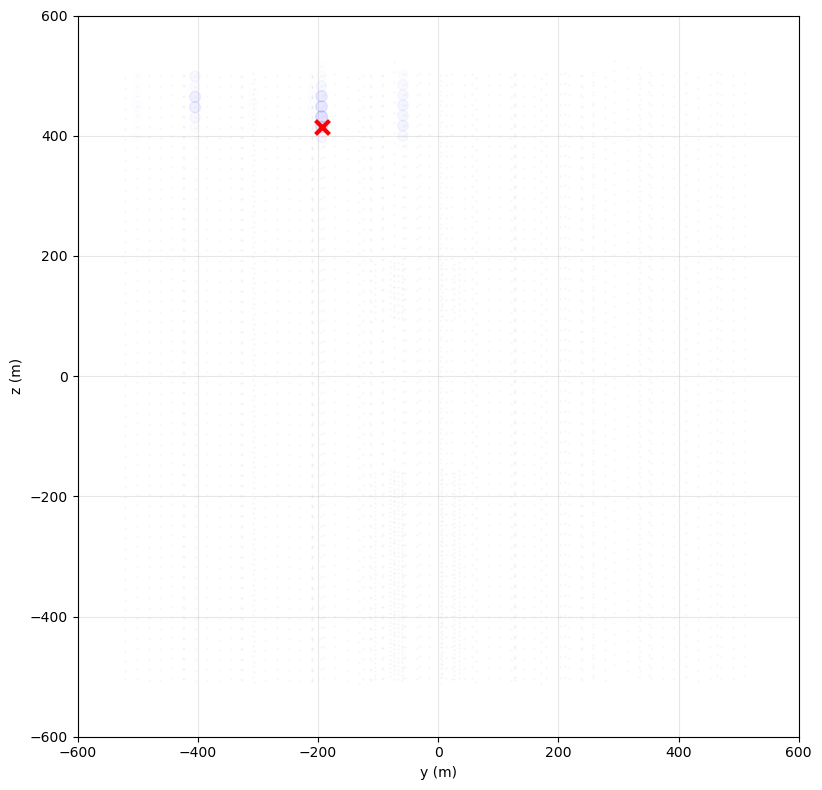

Pulse 6: True DOM 1207 -> Predicted DOM 1206 (confidence: 0.110)
         Distance from true position: 17.0m


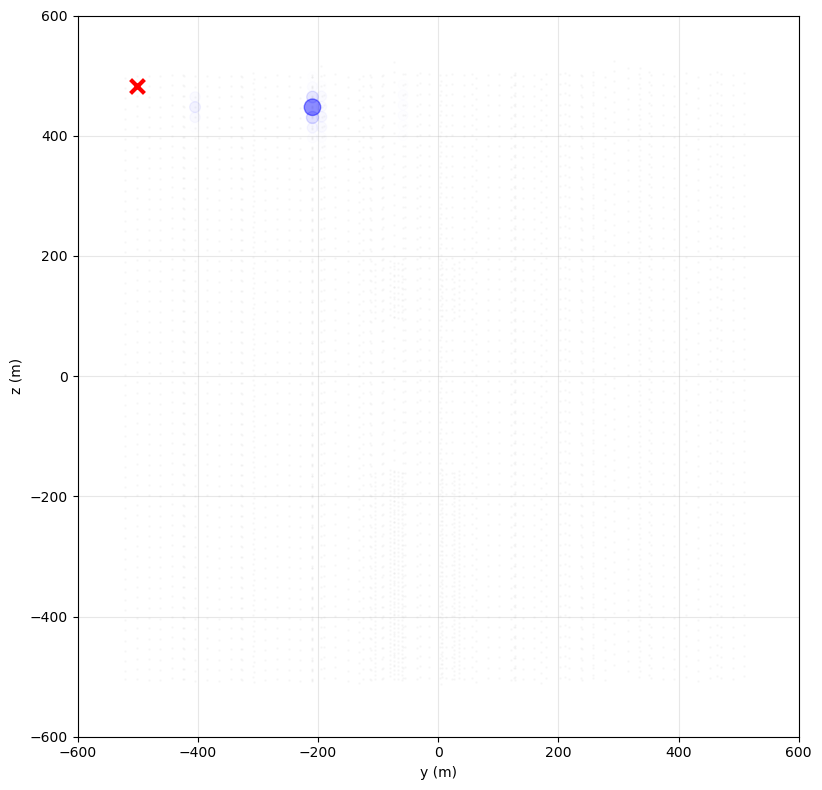

Pulse 7: True DOM 62 -> Predicted DOM 1144 (confidence: 0.452)
         Distance from true position: 545.9m


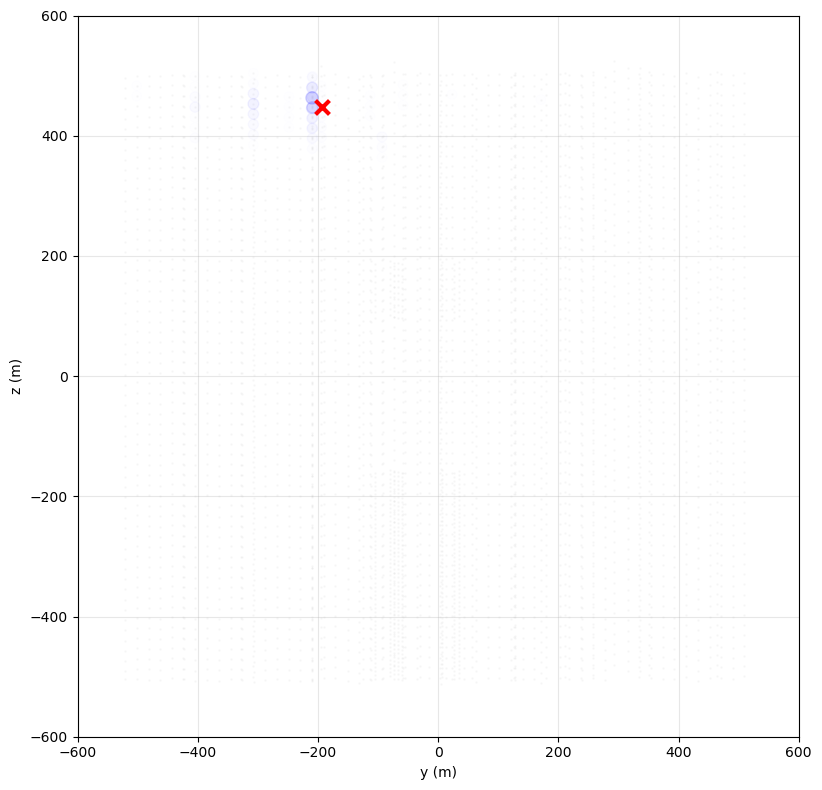

Pulse 8: True DOM 1205 -> Predicted DOM 1083 (confidence: 0.147)
         Distance from true position: 234.2m


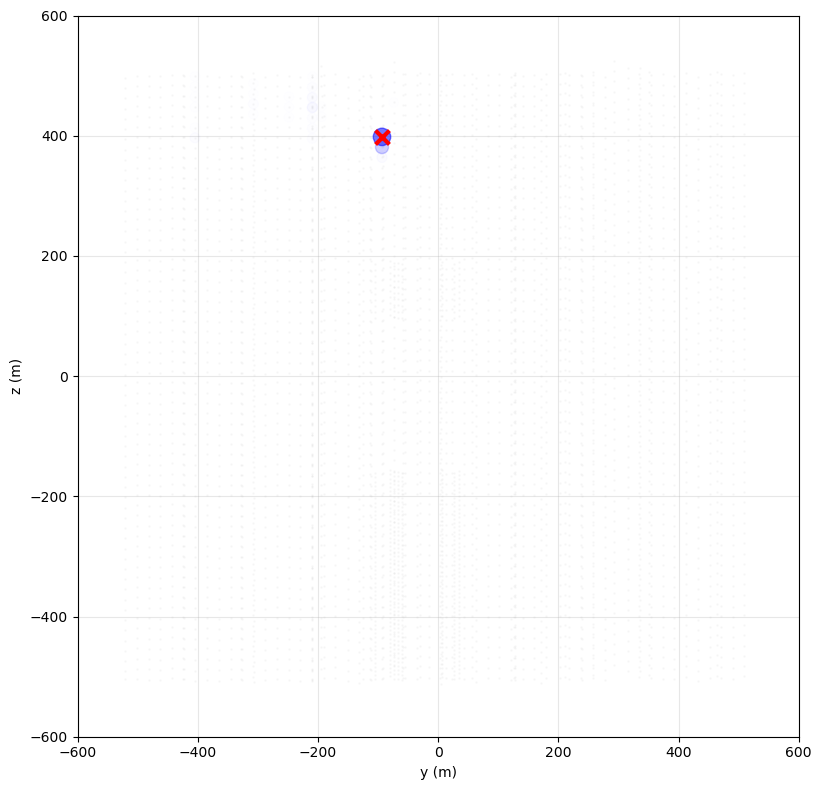

Pulse 9: True DOM 1927 -> Predicted DOM 1927 (confidence: 0.533)
         Distance from true position: 0.0m


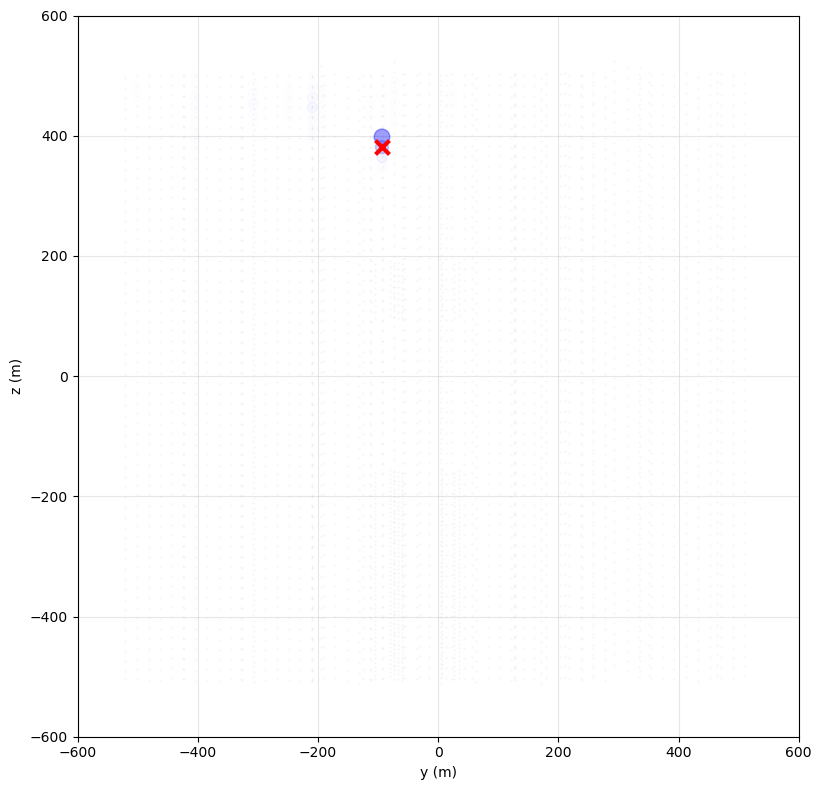

Pulse 10: True DOM 1928 -> Predicted DOM 1927 (confidence: 0.378)
         Distance from true position: 17.0m


In [60]:

plot_masked_predictions_vectorized(x, 65, mask, logits, positions, geometry_df, 
                                 size_scale=500, top_k=5000, max_plots=10)

# Same but a worse model

In [61]:
checkpoint_path = "/groups/pheno/inar/PolarBERT/src/polarbert/checkpoints/results/PolarBERT-xyz-130M-8ep-trap_250907-135856/epoch=00-step=015868.ckpt"

pretrained_model2 = load_pretrained_model(
    config=config,
    checkpoint_path=checkpoint_path,
    device='cuda',
    from_scratch=False
)

INFO:root:Loading checkpoint from: /groups/pheno/inar/PolarBERT/src/polarbert/checkpoints/results/PolarBERT-xyz-130M-8ep-trap_250907-135856/epoch=00-step=015868.ckpt
INFO:root:Loaded pretrained weights successfully!


In [63]:
pretrained_metrics2 = validate_model(
    model=pretrained_model2,
    val_loader=val_loader,
    num_batches=128,
    device='cuda'
)
pretrained_metrics2['avg_loss']

INFO:root:Validation metrics: {'avg_loss': 2.3024464286863804, 'accuracy': 0.2135351532713131, 'total_masked_tokens': 262280, 'total_correct_predictions': 56006, 'batches_processed': 128}


2.3024464286863804

In [64]:
pretrained_model2.embedding.set_manual_mask(fixed_mask)

In [65]:
with torch.no_grad():
    # Get predictions from both models
    logit2, mask2, charge2, padding_mask2 = pretrained_model2(sample_batch)

Event 65: 127 pulses, 24 masked
Charge range: -0.30 to 0.17
Size scale: 500


/lustre/hpc/pheno/inar/mambaforge/envs/polarbert/lib/python3.11/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


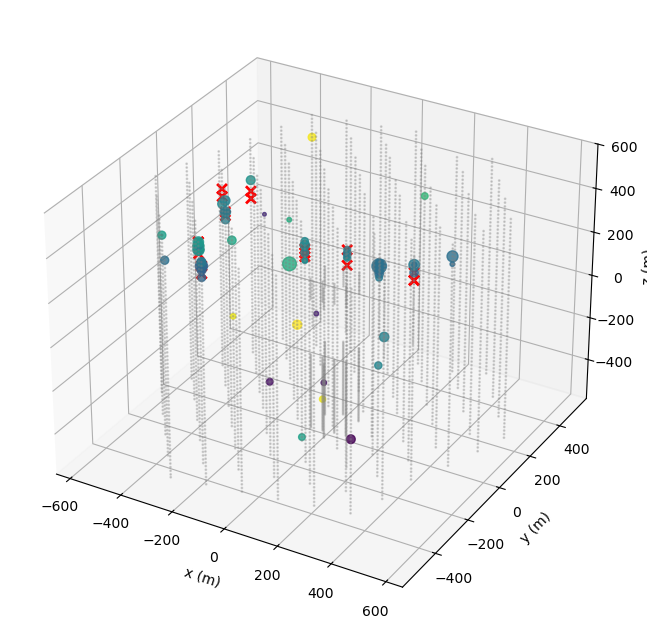

In [66]:
plot_event_with_masks(x, 65, mask2, positions, geometry_df, size_scale=500)

Event 65: 127 pulses, 24 masked
Creating 10 vectorized plots (y-z projection, top 5000)...


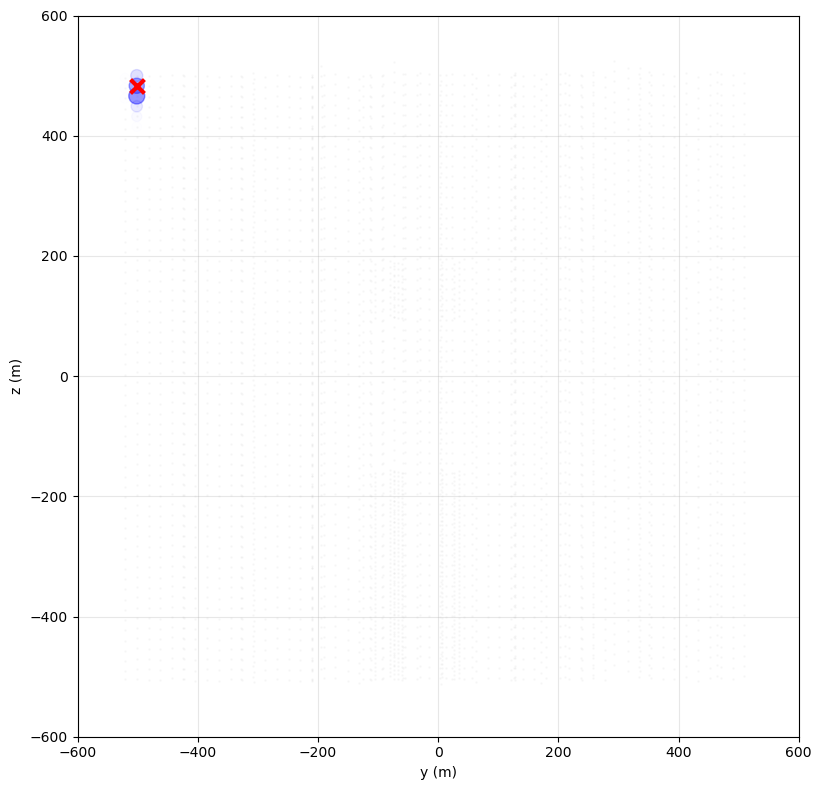

Pulse 1: True DOM 62 -> Predicted DOM 63 (confidence: 0.408)
         Distance from true position: 17.0m


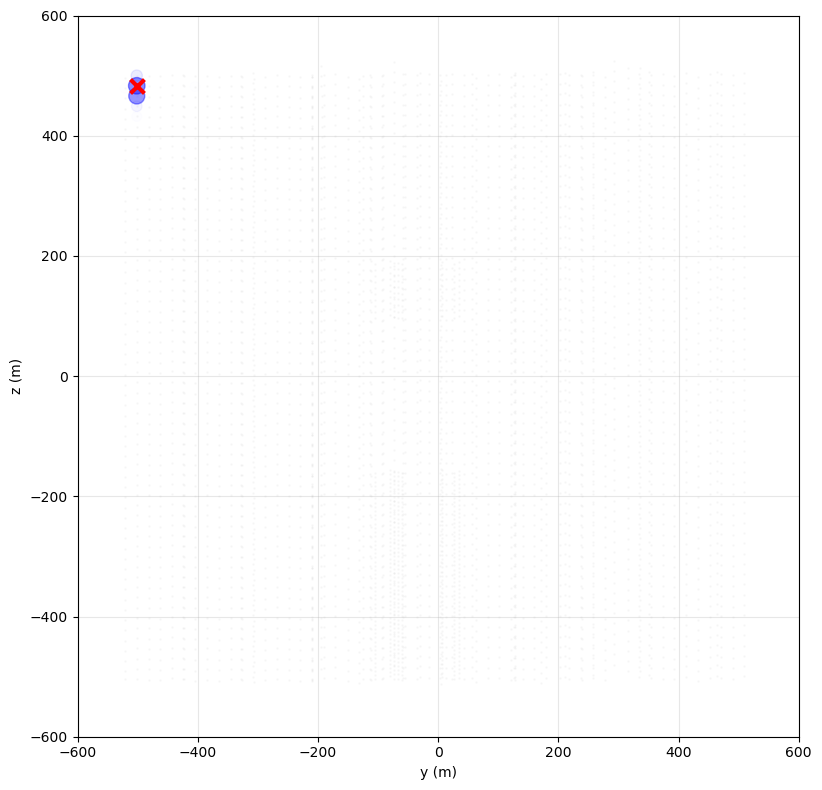

Pulse 2: True DOM 62 -> Predicted DOM 62 (confidence: 0.450)
         Distance from true position: 0.0m


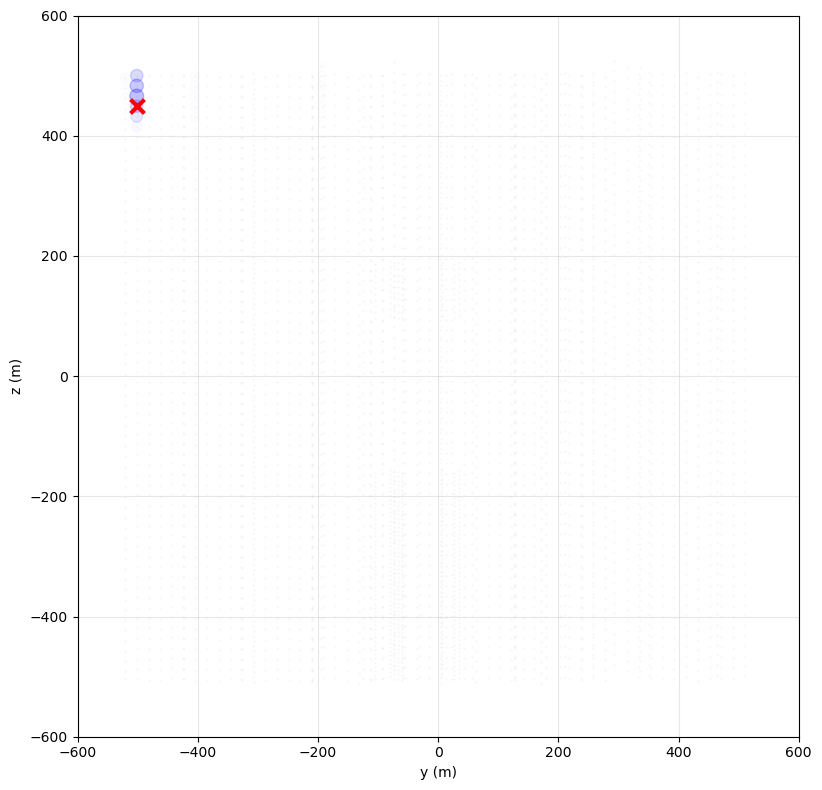

Pulse 3: True DOM 64 -> Predicted DOM 63 (confidence: 0.242)
         Distance from true position: 17.0m


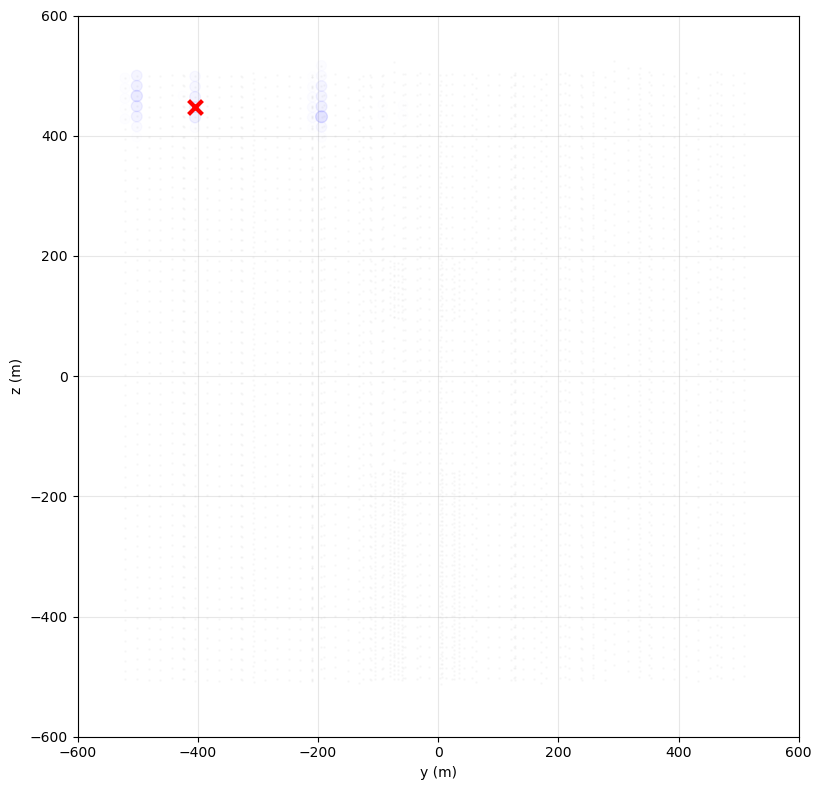

Pulse 4: True DOM 424 -> Predicted DOM 1206 (confidence: 0.105)
         Distance from true position: 688.3m


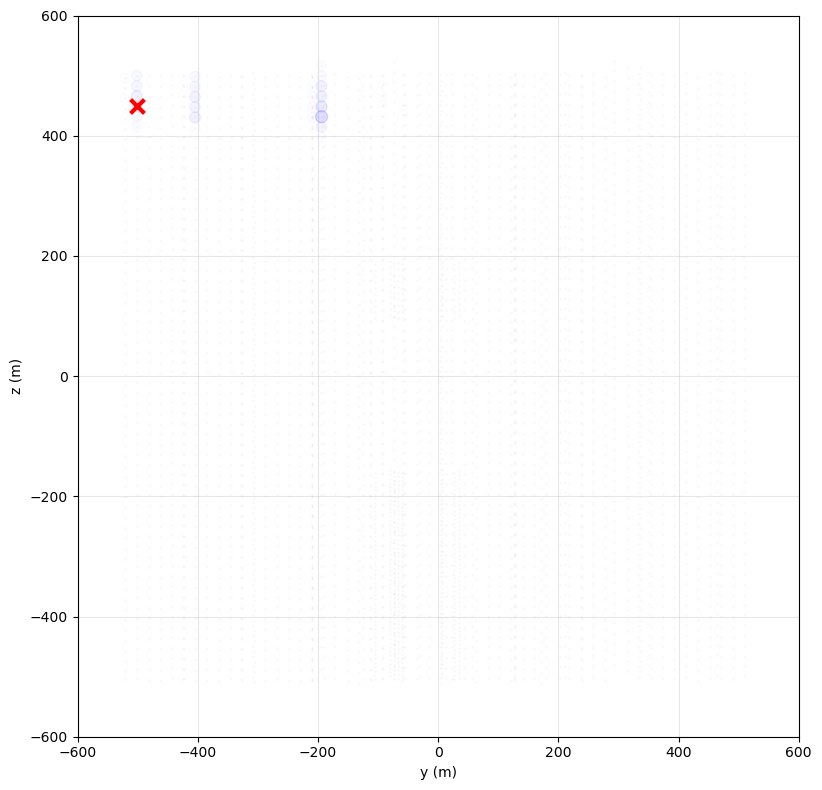

Pulse 5: True DOM 64 -> Predicted DOM 1206 (confidence: 0.130)
         Distance from true position: 653.6m


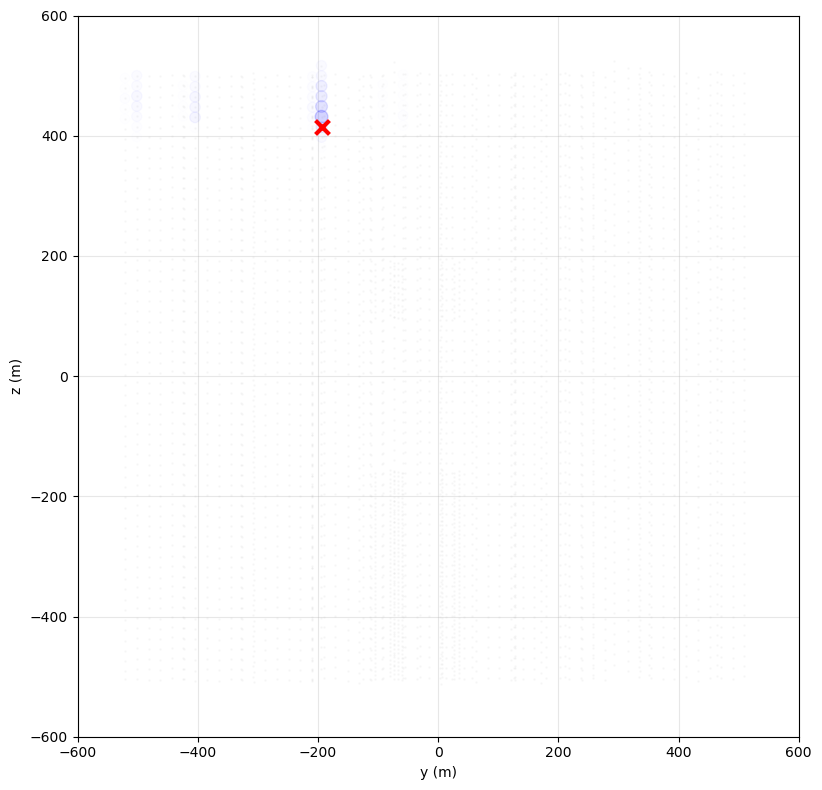

Pulse 6: True DOM 1207 -> Predicted DOM 1206 (confidence: 0.169)
         Distance from true position: 17.0m


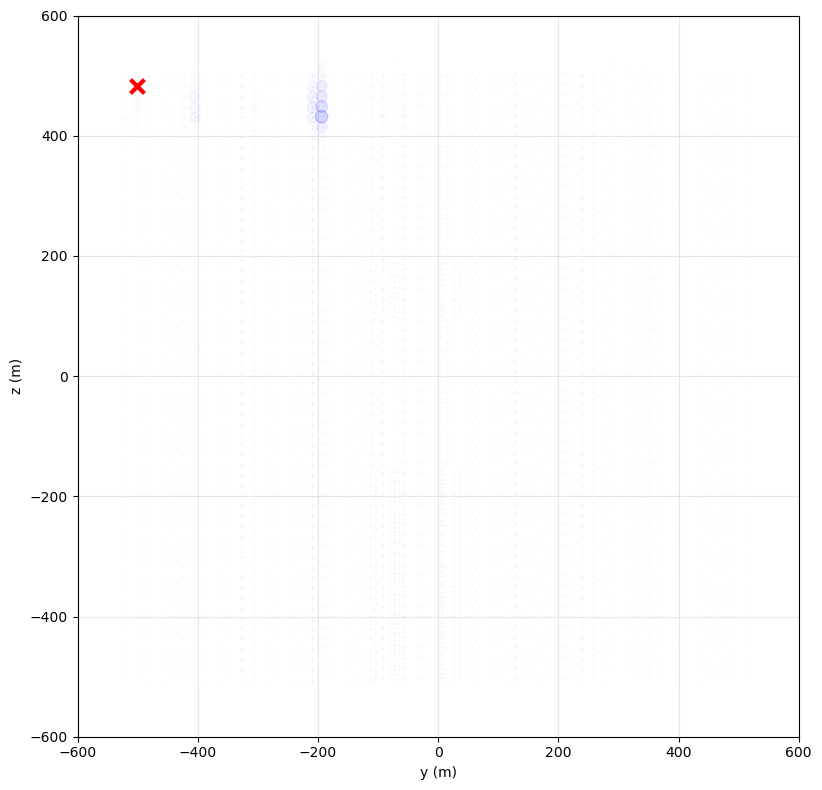

Pulse 7: True DOM 62 -> Predicted DOM 1206 (confidence: 0.161)
         Distance from true position: 655.4m


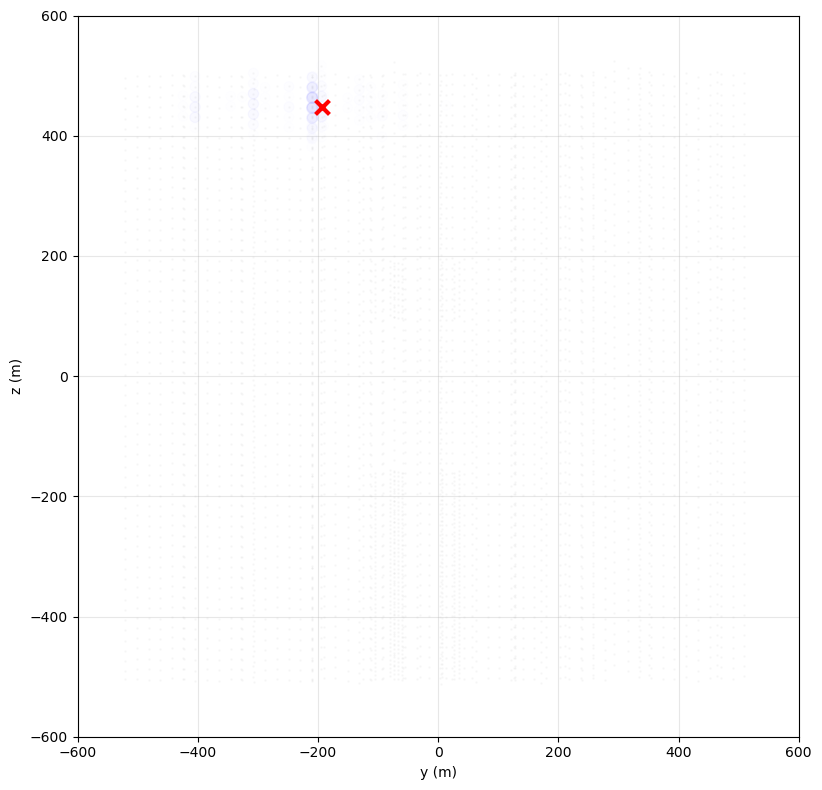

Pulse 8: True DOM 1205 -> Predicted DOM 1083 (confidence: 0.056)
         Distance from true position: 234.2m


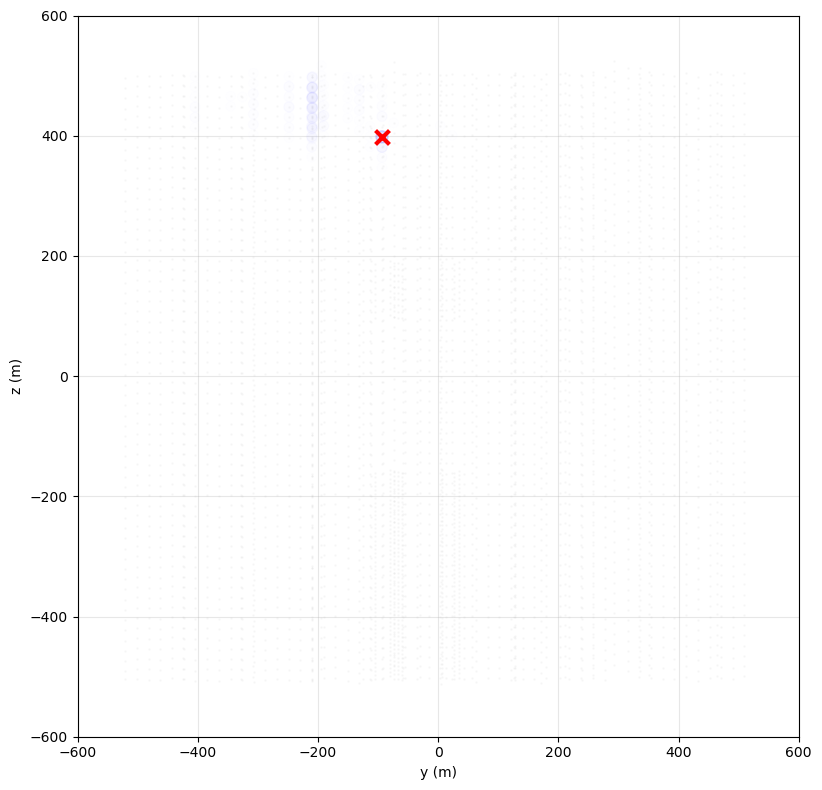

Pulse 9: True DOM 1927 -> Predicted DOM 1927 (confidence: 0.133)
         Distance from true position: 0.0m


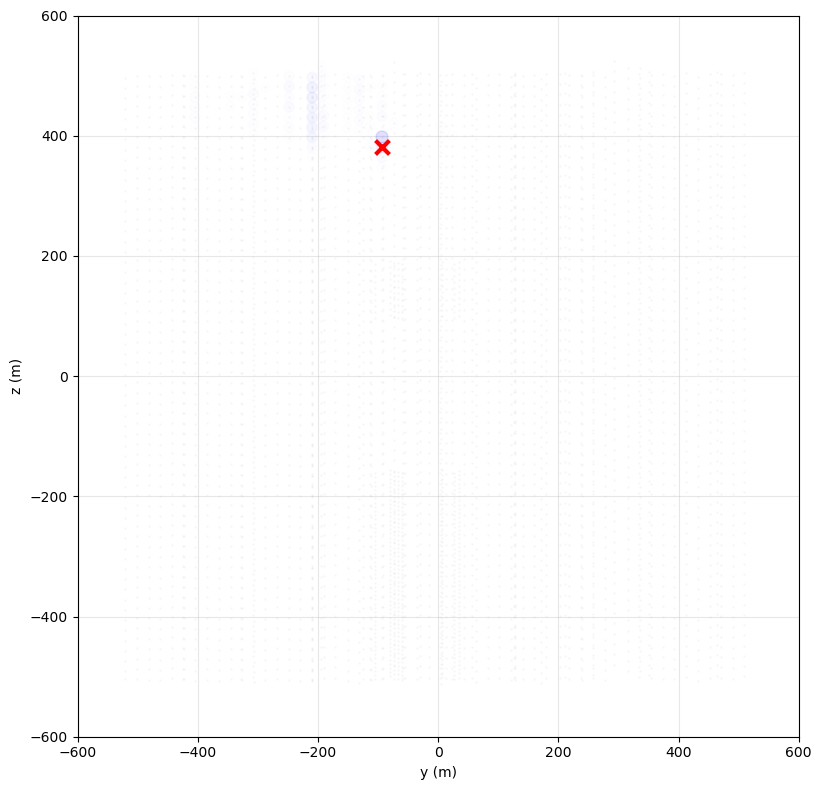

Pulse 10: True DOM 1928 -> Predicted DOM 1927 (confidence: 0.117)
         Distance from true position: 17.0m


In [67]:

plot_masked_predictions_vectorized(x, 65, mask2, logit2, positions, geometry_df, 
                                 size_scale=500, top_k=5000, max_plots=10)

## Model comparisons

In [78]:
def analyze_models_predictions(model1, model2, data_loader, positions, geometry_df, num_batches=5, model1_name="Model 1", model2_name="Model 2"):
    """
    Analyze the relationship between prediction distance and probability for both models.
    
    Args:
        model1, model2: The loaded models
        data_loader: DataLoader to sample batches from
        positions: DOM position tensor
        geometry_df: Sensor geometry dataframe
        num_batches: Number of batches to analyze
        model1_name, model2_name: Names for the models in the plot
    
    Returns:
        Dictionary with results for both models
    """
    
    # Storage for results
    results = {
        model1_name: {'distances': [], 'probabilities': [], 'true_dom_ids': [], 'pred_dom_ids': []},
        model2_name: {'distances': [], 'probabilities': [], 'true_dom_ids': [], 'pred_dom_ids': []}
    }
    
    all_positions = positions.numpy()
    
    print(f"Analyzing {num_batches} batches...")
    
    for batch_idx, batch in enumerate(data_loader):
        if batch_idx >= num_batches:
            break
            
        print(f"Processing batch {batch_idx + 1}/{num_batches}")
        
        # Move batch to device
        batch = batch_to_device(batch, device='cuda')
        
        # Process both models
        for model, model_name in [(model1, model1_name), (model2, model2_name)]:
            
            # Create a mask for this batch (using same seed for consistency)
            batch_mask = create_mask(batch[0], config, seed=42)
            model.embedding.set_manual_mask(batch_mask)
            
            # Get model predictions - pass just the input part (x, l)
            with torch.no_grad():
                logits, mask, charge, padding_mask = model(batch[0])
            
            (x, l), (y, c) = batch
            
            # Find masked positions
            mask_positions = (mask == 1) & (x['dom_id'] > 0)  # Exclude padding
            
            if not mask_positions.any():
                continue
            
            # Get true DOM IDs for masked pulses
            true_dom_ids = x['dom_id'][mask_positions].cpu().numpy()
            
            # Get logits for masked positions
            masked_logits = logits[mask_positions]  # Shape: (num_masked, vocab_size)
            
            # Convert to probabilities and get top predictions
            probs = torch.softmax(masked_logits, dim=-1)
            top_probs, top_indices = torch.max(probs, dim=-1)
            
            top_probs = top_probs.cpu().numpy()
            top_indices = top_indices.cpu().numpy()
            
            # Calculate distances
            for i, (true_dom, pred_dom, prob) in enumerate(zip(true_dom_ids, top_indices, top_probs)):
                
                # Skip if predicted DOM is padding (0) or out of range
                if pred_dom == 0 or pred_dom >= len(all_positions):
                    continue
                    
                # Get positions
                true_pos = all_positions[true_dom]
                pred_pos = all_positions[pred_dom]
                
                # Calculate Euclidean distance
                distance = np.linalg.norm(true_pos - pred_pos)
                
                # Store results
                results[model_name]['distances'].append(distance)
                results[model_name]['probabilities'].append(prob)
                results[model_name]['true_dom_ids'].append(true_dom)
                results[model_name]['pred_dom_ids'].append(pred_dom)
    
    # Convert lists to numpy arrays
    for model_name in results:
        for key in results[model_name]:
            results[model_name][key] = np.array(results[model_name][key])
        
        print(f"{model_name}: {len(results[model_name]['distances'])} masked pulses analyzed")
    
    return results

def plot_distance_vs_probability(results, figsize=(12, 8)):
    """
    Create scatter plot of distance vs probability for both models.
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    colors = ['blue', 'red']
    model_names = list(results.keys())
    
    for i, model_name in enumerate(model_names):
        distances = results[model_name]['distances']
        probabilities = results[model_name]['probabilities']
        
        # Create scatter plot
        ax1.scatter(probabilities, distances, alpha=0.6, s=10, 
                   color=colors[i], label=model_name)
        
        # Log scale version
        ax2.scatter(probabilities, distances, alpha=0.6, s=10, 
                   color=colors[i], label=model_name)
    
    # Regular scale
    ax1.set_xlabel('Top Prediction Probability')
    ax1.set_ylabel('Distance to True DOM (m)')
    ax1.set_title('Distance vs Probability (Linear Scale)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Log scale
    ax2.set_xlabel('Top Prediction Probability')
    ax2.set_ylabel('Distance to True DOM (m)')
    ax2.set_yscale('log')
    ax2.set_title('Distance vs Probability (Log Scale)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nSummary Statistics:")
    print("-" * 50)
    for model_name in model_names:
        distances = results[model_name]['distances']
        probabilities = results[model_name]['probabilities']
        
        print(f"\n{model_name}:")
        print(f"  Mean distance: {np.mean(distances):.2f} m")
        print(f"  Median distance: {np.median(distances):.2f} m")
        print(f"  Mean probability: {np.mean(probabilities):.4f}")
        print(f"  Median probability: {np.median(probabilities):.4f}")
        print(f"  Total predictions: {len(distances)}")

print("Functions loaded! You can now run the analysis.")

Functions loaded! You can now run the analysis.


In [79]:
# Run the analysis on both models
results = analyze_models_predictions(
    pretrained_model, pretrained_model2, 
    val_loader, positions, geometry_df, 
    num_batches=10,  # Adjust this number based on how much data you want
    model1_name="PolarBERT Model 1", 
    model2_name="PolarBERT Model 2"
)

INFO:root:Created mask with 2068 masked tokens out of 8252 eligible tokens


Analyzing 10 batches...
Processing batch 1/10


INFO:root:Created mask with 2068 masked tokens out of 8252 eligible tokens
INFO:root:Created mask with 2025 masked tokens out of 8322 eligible tokens
INFO:root:Created mask with 2025 masked tokens out of 8322 eligible tokens
INFO:root:Created mask with 2025 masked tokens out of 8322 eligible tokens
INFO:root:Created mask with 2025 masked tokens out of 8322 eligible tokens
INFO:root:Created mask with 1848 masked tokens out of 7263 eligible tokens
INFO:root:Created mask with 1848 masked tokens out of 7263 eligible tokens
INFO:root:Created mask with 1848 masked tokens out of 7263 eligible tokens
INFO:root:Created mask with 1848 masked tokens out of 7263 eligible tokens
INFO:root:Created mask with 2145 masked tokens out of 8560 eligible tokens
INFO:root:Created mask with 2145 masked tokens out of 8560 eligible tokens
INFO:root:Created mask with 2145 masked tokens out of 8560 eligible tokens
INFO:root:Created mask with 2145 masked tokens out of 8560 eligible tokens
INFO:root:Created mask wi

Processing batch 2/10
Processing batch 3/10
Processing batch 4/10
Processing batch 5/10


INFO:root:Created mask with 1976 masked tokens out of 7729 eligible tokens
INFO:root:Created mask with 1976 masked tokens out of 7729 eligible tokens
INFO:root:Created mask with 1976 masked tokens out of 7729 eligible tokens
INFO:root:Created mask with 2139 masked tokens out of 8697 eligible tokens
INFO:root:Created mask with 2139 masked tokens out of 8697 eligible tokens
INFO:root:Created mask with 2139 masked tokens out of 8697 eligible tokens
INFO:root:Created mask with 2139 masked tokens out of 8697 eligible tokens
INFO:root:Created mask with 1946 masked tokens out of 7751 eligible tokens
INFO:root:Created mask with 1946 masked tokens out of 7751 eligible tokens
INFO:root:Created mask with 1946 masked tokens out of 7751 eligible tokens
INFO:root:Created mask with 1946 masked tokens out of 7751 eligible tokens
INFO:root:Created mask with 2001 masked tokens out of 7856 eligible tokens
INFO:root:Created mask with 2001 masked tokens out of 7856 eligible tokens
INFO:root:Created mask wi

Processing batch 6/10
Processing batch 7/10
Processing batch 8/10
Processing batch 9/10


INFO:root:Created mask with 1879 masked tokens out of 7510 eligible tokens
INFO:root:Created mask with 1879 masked tokens out of 7510 eligible tokens
INFO:root:Created mask with 1879 masked tokens out of 7510 eligible tokens


Processing batch 10/10
PolarBERT Model 1: 20083 masked pulses analyzed
PolarBERT Model 2: 20083 masked pulses analyzed


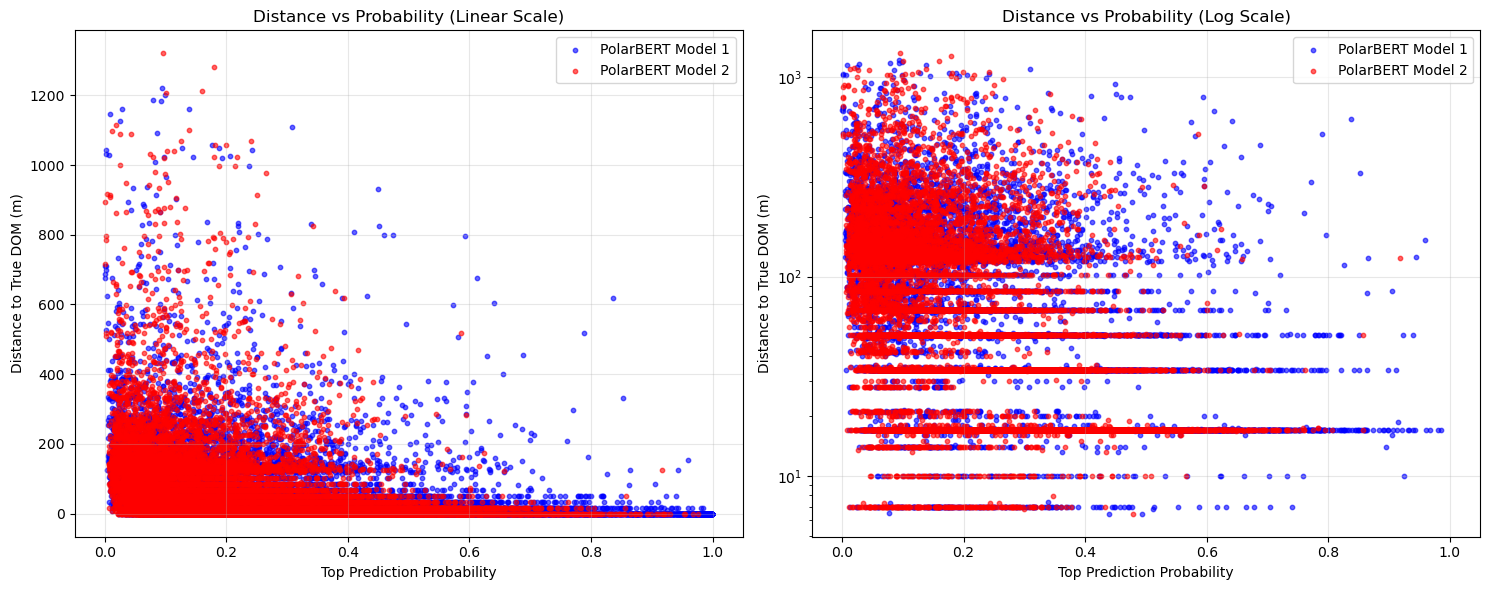


Summary Statistics:
--------------------------------------------------

PolarBERT Model 1:
  Mean distance: 61.95 m
  Median distance: 17.03 m
  Mean probability: 0.2978
  Median probability: 0.2431
  Total predictions: 20083

PolarBERT Model 2:
  Mean distance: 65.61 m
  Median distance: 34.04 m
  Mean probability: 0.2347
  Median probability: 0.2101
  Total predictions: 20083


In [80]:
# Create the scatter plots
plot_distance_vs_probability(results, figsize=(15, 6))

In [81]:
# Additional analysis: compute correlations and create detailed comparison
import scipy.stats as stats

print("Correlation Analysis:")
print("=" * 50)

for model_name in results.keys():
    distances = results[model_name]['distances']
    probabilities = results[model_name]['probabilities']
    
    # Compute Pearson correlation
    corr_pearson, p_value_pearson = stats.pearsonr(probabilities, distances)
    
    # Compute Spearman correlation (rank-based, good for non-linear relationships)
    corr_spearman, p_value_spearman = stats.spearmanr(probabilities, distances)
    
    print(f"\n{model_name}:")
    print(f"  Pearson correlation: {corr_pearson:.4f} (p-value: {p_value_pearson:.2e})")
    print(f"  Spearman correlation: {corr_spearman:.4f} (p-value: {p_value_spearman:.2e})")
    
    # Calculate percentage of predictions within certain distance thresholds
    distances_sorted = np.sort(distances)
    n_total = len(distances)
    
    thresholds = [10, 50, 100, 200, 500]  # meters
    print(f"  Distance distribution:")
    for threshold in thresholds:
        pct = 100 * np.sum(distances <= threshold) / n_total
        print(f"    ≤ {threshold}m: {pct:.1f}%")
    
    # High confidence predictions (top 10% probability)
    high_conf_threshold = np.percentile(probabilities, 90)
    high_conf_mask = probabilities >= high_conf_threshold
    high_conf_distances = distances[high_conf_mask]
    
    print(f"  High confidence predictions (≥{high_conf_threshold:.3f} prob):")
    print(f"    Count: {len(high_conf_distances)}")
    print(f"    Mean distance: {np.mean(high_conf_distances):.2f}m")
    print(f"    Median distance: {np.median(high_conf_distances):.2f}m")

Correlation Analysis:

PolarBERT Model 1:
  Pearson correlation: -0.3570 (p-value: 0.00e+00)
  Spearman correlation: -0.5691 (p-value: 0.00e+00)
  Distance distribution:
    ≤ 10m: 28.9%
    ≤ 50m: 62.5%
    ≤ 100m: 76.2%
    ≤ 200m: 93.7%
    ≤ 500m: 99.2%
  High confidence predictions (≥0.603 prob):
    Count: 2009
    Mean distance: 10.30m
    Median distance: 0.00m

PolarBERT Model 2:
  Pearson correlation: -0.3712 (p-value: 0.00e+00)
  Spearman correlation: -0.5497 (p-value: 0.00e+00)
  Distance distribution:
    ≤ 10m: 21.8%
    ≤ 50m: 61.4%
    ≤ 100m: 75.1%
    ≤ 200m: 93.7%
    ≤ 500m: 99.0%
  High confidence predictions (≥0.446 prob):
    Count: 2009
    Mean distance: 11.30m
    Median distance: 0.00m
